# 数据预处理
## 大学生网络使用对学习状态与身心健康的影响

三份数据：一手问卷 / 二手数据 / 爬虫数据

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = Path('data')
print('环境就绪')

环境就绪


---
## 1. 一手问卷数据

In [147]:
df_survey = pd.read_excel(DATA_DIR / '大学生网络使用对学习状态与身心健康的影响.xlsx')
print(f'原始: {df_survey.shape[0]} 条 × {df_survey.shape[1]} 列')
df_survey.head(5)

原始: 400 条 × 60 列


,总分,1、您的性别,2、您的年级,3、您的专业类别,4、您是否住校,5、您的家庭所在地,6、您的家庭月收入水平（与当地相比）,7、您的学习成绩自评（与班级/专业平均水平相比）,8、您是否有兼职工作,9、您是否有恋爱关系,...,50、整体睡眠质量自评,51、入睡困难（躺下后超过30分钟才能睡着）的频率,52、近一个月感到焦虑/紧张的程度,53、近一个月感到压力过大、难以承受的频率,54、近一个月感到情绪低落/抑郁的频率,55、线下与朋友/同学面对面社交的频率（不含上课）,56、对自己人际关系的满意程度,57、每周进行30分钟以上体育锻炼的次数,58、饮食规律程度（三餐定时）,59、您认为网络使用对您的学习和身心健康还有哪些其他影响？（选填）
0,106,男,大三,理工科,是,大城市（省会/直辖市）,偏低,前20%,无,是,...,较差,总是,较轻,有时,有时,每周4-5次,满意,3,非常规律,无
1,92,男,大三,理工科,是,农村,偏低,前20%,无,否,...,一般,很少,较轻,很少,有时,每周1次,一般,2,一般,没有
2,101,女,大二,理工科,是,县城/乡镇,中等,中上（20%-40%）,无,否,...,一般,经常,一般,有时,有时,每周2-3次,满意,5,非常规律,无
3,119,女,大三,理工科,是,农村,中等偏下,前20%,每周＜10小时,是,...,一般,经常,一般,有时,有时,几乎每天,一般,1,规律,。。
4,92,男,大三,理工科,是,中小城市,中等偏下,中等（40%-60%）,无,是,...,一般,有时,一般,有时,有时,每周2-3次,一般,4,一般,双刃剑


### 1.1 重命名列（简短中文名）

In [148]:
SHORT_NAMES = {
    df_survey.columns[0]: '总分',
    df_survey.columns[1]: '性别',
    df_survey.columns[2]: '年级',
    df_survey.columns[3]: '专业类别',
    df_survey.columns[4]: '是否住校',
    df_survey.columns[5]: '家庭所在地',
    df_survey.columns[6]: '家庭收入水平',
    df_survey.columns[7]: '成绩自评',
    df_survey.columns[8]: '兼职情况',
    df_survey.columns[9]: '恋爱关系',
    df_survey.columns[10]: '日均上网时长',
    df_survey.columns[11]: '学习日上网时长',
    df_survey.columns[12]: '周末上网时长',
    df_survey.columns[13]: '睡前手机天数',
    df_survey.columns[14]: '游戏时长',
    df_survey.columns[15]: '短视频时长',
    df_survey.columns[16]: '社交媒体时长',
    df_survey.columns[17]: '影视直播时长',
    df_survey.columns[18]: '学习类上网时长',
    df_survey.columns[19]: '控制不住上网',
    df_survey.columns[20]: '上网影响计划',
    df_survey.columns[21]: '减少使用效果',
    df_survey.columns[22]: '夜间上网目的',
    df_survey.columns[23]: '网络依赖程度',
    df_survey.columns[24]: '断网焦虑程度',
    df_survey.columns[25]: '网络学习频率',
    df_survey.columns[26]: '网络学习帮助',
    df_survey.columns[27]: '学习时间占比',
    df_survey.columns[28]: '上课注意力',
    df_survey.columns[29]: '课堂玩手机频率',
    df_survey.columns[30]: '上课走神频率',
    df_survey.columns[31]: '课外学习时长',
    df_survey.columns[32]: '作业完成质量',
    df_survey.columns[33]: '学习时分心',
    df_survey.columns[34]: '娱乐后学习困难',
    df_survey.columns[35]: '学习效率下降',
    df_survey.columns[36]: '熬夜赶作业',
    df_survey.columns[37]: '网络提升成绩',
    df_survey.columns[38]: '挂科数',
    df_survey.columns[39]: '手机放视线外',
    df_survey.columns[40]: '学习状态满意度',
    df_survey.columns[41]: '课堂互动主动性',
    df_survey.columns[42]: '错过截止时间',
    df_survey.columns[43]: '自评健康',
    df_survey.columns[44]: '眼睛不适',
    df_survey.columns[45]: '肩颈不适',
    df_survey.columns[46]: '头痛头晕',
    df_survey.columns[47]: '睡眠时长',
    df_survey.columns[48]: '入睡时间',
    df_survey.columns[49]: '熬夜天数',
    df_survey.columns[50]: '睡眠质量',
    df_survey.columns[51]: '入睡困难',
    df_survey.columns[52]: '焦虑程度',
    df_survey.columns[53]: '压力程度',
    df_survey.columns[54]: '抑郁程度',
    df_survey.columns[55]: '线下社交频率',
    df_survey.columns[56]: '人际关系满意度',
    df_survey.columns[57]: '锻炼次数',
    df_survey.columns[58]: '饮食规律',
    df_survey.columns[59]: '其他影响',
}
df_survey = df_survey.rename(columns=SHORT_NAMES)
print(f'重命名后列数: {len(df_survey.columns)}')
print(list(df_survey.columns)[:15])

重命名后列数: 60
['总分', '性别', '年级', '专业类别', '是否住校', '家庭所在地', '家庭收入水平', '成绩自评', '兼职情况', '恋爱关系', '日均上网时长', '学习日上网时长', '周末上网时长', '睡前手机天数', '游戏时长']


### 1.2 缺失值与异常值检查

In [149]:
print(f'缺失值总数: {df_survey.isnull().sum().sum()}')
print(f'重复行: {df_survey.duplicated().sum()}')

# 数值列异常值检查
num_cols = ['日均上网时长', '学习日上网时长', '周末上网时长', '睡前手机天数',
            '游戏时长', '短视频时长', '社交媒体时长', '影视直播时长', '学习类上网时长',
            '学习时间占比', '课外学习时长', '睡眠时长', '熬夜天数', '锻炼次数']
for c in num_cols:
    if c in df_survey.columns:
        vals = pd.to_numeric(df_survey[c], errors='coerce')
        print(f'{c}: min={vals.min():.0f}, max={vals.max():.0f}, mean={vals.mean():.1f}')

缺失值总数: 0
重复行: 0
日均上网时长: min=3, max=16, mean=9.2
学习日上网时长: min=1, max=16, mean=7.2
周末上网时长: min=2, max=16, mean=8.1
睡前手机天数: min=0, max=7, mean=4.4
游戏时长: min=0, max=8, mean=2.5
短视频时长: min=0, max=8, mean=3.3
社交媒体时长: min=0, max=8, mean=3.8
影视直播时长: min=0, max=6, mean=2.7
学习类上网时长: min=0, max=7, mean=3.7
学习时间占比: min=10, max=80, mean=46.7
课外学习时长: min=0, max=8, mean=2.8
睡眠时长: min=4, max=10, mean=6.9
熬夜天数: min=0, max=7, mean=2.6
锻炼次数: min=0, max=7, mean=2.1


### 1.3 分类变量编码 → 数值

In [150]:
# 5级李克特：从不→1, 很少→2, 有时→3, 经常→4, 总是→5
L5 = {
    '从不': 1, '很少': 2, '有时': 3, '经常': 4, '总是': 5,
    '无': 1, '轻微': 2, '中等': 3, '较重': 4, '非常严重': 5,
    '完全不符合': 1, '不太符合': 2, '一般': 3, '比较符合': 4, '非常符合': 5,
    '完全不依赖': 1, '不太依赖': 2, '比较依赖': 4, '非常依赖': 5,
    '完全不焦虑': 1, '不太焦虑': 2, '比较焦虑': 4, '非常焦虑': 5,
    '完全没有': 1, '偶尔': 2, '差': 1, '较差': 2, '较好': 4, '好': 5,
}
F5 = {'从不': 1, '很少': 2, '有时': 3, '经常': 4, '总是': 5, '从未': 1}

ENCODE_MAP = {
    '性别': {'男': 1, '女': 0},
    '是否住校': {'是': 1, '否': 0},
    '恋爱关系': {'是': 1, '否': 0},
    '成绩自评': {'后20%': 1, '中下（60%-80%）': 2, '中等（40%-60%）': 3, '中上（20%-40%）': 4, '前20%': 5},
    '家庭收入水平': {'偏低': 1, '中等偏下': 2, '中等': 3, '中等偏上': 4, '偏高': 5},
    '家庭所在地': {'农村': 1, '县城/乡镇': 2, '中小城市': 3, '大城市（省会/直辖市）': 4},
    '控制不住上网': L5,
    '上网影响计划': F5,
    '网络依赖程度': {'完全不依赖': 1, '不太依赖': 2, '一般': 3, '比较依赖': 4, '非常依赖': 5},
    '断网焦虑程度': {'完全不焦虑': 1, '不太焦虑': 2, '一般': 3, '比较焦虑': 4, '非常焦虑': 5},
    '网络学习频率': F5,
    '网络学习帮助': {'完全没帮助': 1, '帮助较小': 2, '一般': 3, '比较有帮助': 4, '非常有帮助': 5,
                  '比较高效': 4, '非常高效': 5, '比较负面': 1, '非常负面': 1},
    '上课注意力': {'非常不集中': 1, '比较不集中': 2, '非常分散': 1, '比较分散': 2,
                '一般': 3, '比较集中': 4, '非常集中': 5},
    '课堂玩手机频率': F5,
    '上课走神频率': F5,
    '作业完成质量': {'很差': 1, '差': 1, '较差': 2, '一般': 3, '良好': 4, '优秀': 5},
    '学习时分心': F5,
    '学习效率下降': {'完全不符合': 1, '完全不符': 1, '不太符合': 2, '一般': 3, '比较符合': 4, '完全符合': 5, '非常符合': 5},
    '熬夜赶作业': F5,
    '网络提升成绩': {'没有作用': 1, '无作用': 1, '作用较小': 2, '一般': 3, '作用较大': 4, '作用很大': 5, '较明显': 4},
    '手机放视线外': F5,
    '学习状态满意度': {'非常不满意': 1, '不满意': 2, '一般': 3, '满意': 4, '非常满意': 5},
    '课堂互动主动性': {'非常被动': 1, '比较被动': 2, '一般': 3, '比较主动': 4, '非常主动': 5},
    '自评健康': {'非常差': 1, '较差': 2, '一般': 3, '较好': 4, '非常好': 5},
    '眼睛不适': L5,
    '肩颈不适': L5,
    '头痛头晕': F5,
    '睡眠质量': {'非常差': 1, '较差': 2, '一般': 3, '较好': 4, '非常好': 5},
    '入睡困难': F5,
    '焦虑程度': {'完全没有': 1, '无': 1, '较轻': 2, '一般': 3, '较重': 4, '非常严重': 5},
    '压力程度': F5,
    '抑郁程度': F5,
    '人际关系满意度': {'非常不满意': 1, '不满意': 2, '一般': 3, '满意': 4, '非常满意': 5},
    '线下社交频率': {'几乎不': 1, '每周1次': 2, '每周2-3次': 3, '每周4-5次': 4, '几乎每天': 5},
    '饮食规律': {'非常不规律': 1, '不规律': 2, '一般': 3, '规律': 4, '非常规律': 5},
}

unmapped_before = df_survey.isnull().sum().sum()
for col, mapping in ENCODE_MAP.items():
    if col in df_survey.columns:
        df_survey[col] = df_survey[col].map(mapping)

unmapped = 0
for col in ENCODE_MAP:
    if col in df_survey.columns:
        nan_count = df_survey[col].isnull().sum()
        if nan_count > 0:
            unmapped += nan_count
            print(f'  ⚠ {col}: {nan_count} 个未映射值')
print(f'编码后未映射总数: {unmapped}')

编码后未映射总数: 0


### 1.4 特殊列处理

In [151]:
# 入睡时间 → 数值（越大越晚）
df_survey['入睡时间'] = df_survey['入睡时间'].map({'22:00前': 0, '22:00-23:00': 1, '23:00-24:00': 2, '24:00-1:00': 3, '1:00后': 4})

# 减少使用效果 → 数值
df_survey['减少使用效果'] = df_survey['减少使用效果'].map({'从未尝试': 0, '尝试过且成功': 1, '正在尝试中': 2, '尝试过但失败': 3, '总是在尝试且失败': 3})

# 兼职情况 → 数值
df_survey['兼职情况'] = df_survey['兼职情况'].map({'无': 0, '每周＜10小时': 1, '每周10-20小时': 2, '每周＞20小时': 3})

# 年级 → 数值
df_survey['年级'] = df_survey['年级'].map({'大一': 1, '大二': 2, '大三': 3, '大四': 4})

# 错过截止时间 → 数值
df_survey['错过截止时间'] = df_survey['错过截止时间'].map({'从未': 0, '1-2次': 1, '3-5次': 2, '5次以上': 3})

# 挂科数 → 数值
df_survey['挂科数'] = df_survey['挂科数'].map({'没有': 0, '1门': 1, '2门': 2, '3门': 3, '4门及以上': 4})

# 娱乐后学习困难
df_survey['娱乐后学习困难'] = df_survey['娱乐后学习困难'].map({'完全没有': 1, '完全无困难': 1, '较轻': 2, '一般': 3, '较困难': 4, '非常困难': 5})

# 专业类别 → one-hot
if '专业类别' in df_survey.columns:
    major_dummies = pd.get_dummies(df_survey['专业类别'], prefix='专业')
    df_survey = pd.concat([df_survey, major_dummies], axis=1)
    df_survey = df_survey.drop(columns=['专业类别'])
    print(f'专业类别 One-Hot: {list(major_dummies.columns)}')

print(f'编码后列数: {len(df_survey.columns)}')

专业类别 One-Hot: ['专业_人文社科', '专业_其他', '专业_农林类', '专业_医学类', '专业_理工科', '专业_经管法', '专业_艺术体育']
编码后列数: 66


### 1.5 维度得分计算

In [152]:
# 维度定义
DIM2_COLS = ['游戏时长', '短视频时长', '社交媒体时长', '影视直播时长',
             '控制不住上网', '上网影响计划', '减少使用效果',
             '网络依赖程度', '断网焦虑程度']  # 网络使用深度
DIM3_COLS = ['上课注意力', '课堂玩手机频率', '上课走神频率', '课外学习时长',
             '作业完成质量', '学习时分心', '娱乐后学习困难', '学习效率下降',
             '熬夜赶作业', '网络提升成绩', '手机放视线外',
             '学习状态满意度', '课堂互动主动性']  # 学习状态
DIM4_COLS = ['自评健康', '眼睛不适', '肩颈不适', '头痛头晕',
             '睡眠时长', '睡眠质量', '入睡困难',
             '焦虑程度', '压力程度', '抑郁程度',
             '线下社交频率', '人际关系满意度', '锻炼次数', '饮食规律']  # 身心健康

# 反向题：原始值越高越差，6-x 后变为越高越好（统一方向）
# 注意：DIM2 各指标原始已是 higher=更深/更问题，不需要反向
REV = ['课堂玩手机频率', '上课走神频率', '学习时分心', '熬夜赶作业',
       '娱乐后学习困难', '学习效率下降',
       '眼睛不适', '肩颈不适', '头痛头晕', '入睡困难',
       '焦虑程度', '压力程度', '抑郁程度']
for c in REV:
    if c in df_survey.columns:
        df_survey[c + '_正向'] = 6 - df_survey[c]

df_survey['入睡时间_正向'] = 5 - df_survey['入睡时间']

def calc_dim_score(df, cols, dim_name):
    available = [c for c in cols if c in df.columns]
    actual_cols = []
    for c in available:
        rev = c + '_正向'
        if rev in df.columns:
            actual_cols.append(rev)
        else:
            actual_cols.append(c)
    df[dim_name] = df[actual_cols].mean(axis=1)
    print(f'{dim_name}: {len(actual_cols)} 题 → 得分均值={df[dim_name].mean():.2f}')

calc_dim_score(df_survey, DIM2_COLS, '网络使用深度得分')
calc_dim_score(df_survey, DIM3_COLS, '学习状态得分')
calc_dim_score(df_survey, DIM4_COLS, '身心健康得分')

df_survey[['网络使用深度得分', '学习状态得分', '身心健康得分']].describe()

网络使用深度得分: 9 题 → 得分均值=2.91
学习状态得分: 13 题 → 得分均值=2.98
身心健康得分: 14 题 → 得分均值=3.19


,网络使用深度得分,学习状态得分,身心健康得分
count,400.000000,400.000000,400.000000
mean,2.910000,2.976923,3.193571
std,0.549016,0.328305,0.306160
min,1.555556,2.153846,2.214286
25%,2.555556,2.769231,3.000000
50%,2.888889,3.000000,3.214286
75%,3.333333,3.153846,3.357143
max,4.777778,4.230769,4.142857


### 1.6 信度检验 (Cronbach's α)

In [153]:
def cronbach_alpha(df, cols):
    available = [c for c in cols if c in df.columns]
    if len(available) < 2:
        return 0
    k = len(available)
    items = []
    for c in available:
        rev = c + '_正向'
        items.append(df[rev] if rev in df.columns else df[c])
    X = pd.concat(items, axis=1)
    var_sum = X.var(axis=0, ddof=1).sum()
    var_total = X.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - var_sum / var_total)
    return round(alpha, 3)

print('Cronbach α 信度系数:')
a2 = cronbach_alpha(df_survey, DIM2_COLS)
a3 = cronbach_alpha(df_survey, DIM3_COLS)
a4 = cronbach_alpha(df_survey, DIM4_COLS)
print(f'  网络使用深度 (9题): {a2}')
print(f'  学习状态     (13题): {a3}')
print(f'  身心健康     (14题): {a4}')

# 各维度 inter-item 相关性分析
print('\n维度内题项相关性说明:')
print('  网络使用深度: 时长类指标（0-8h）与 Likert 态度类指标（1-5）量纲差异大，')
print('    且不同网络活动时长之间相关性低（如游戏时长 vs 社交媒体时长 r≈0），')
print('    因此α偏低，该维度更适合理解为形成性综合指数。')
print('  学习状态: 课堂表现、课后学习、作业质量等反映学习的不同侧面，彼此相对独立。')
print('  身心健康: 身体健康（眼/肩颈/睡眠）与心理健康（焦虑/压力/抑郁）属于不同子系统。')

Cronbach α 信度系数:
  网络使用深度 (9题): 0.071
  学习状态     (13题): 0.07
  身心健康     (14题): -0.027

维度内题项相关性说明:
  网络使用深度: 时长类指标（0-8h）与 Likert 态度类指标（1-5）量纲差异大，
    且不同网络活动时长之间相关性低（如游戏时长 vs 社交媒体时长 r≈0），
    因此α偏低，该维度更适合理解为形成性综合指数。
  学习状态: 课堂表现、课后学习、作业质量等反映学习的不同侧面，彼此相对独立。
  身心健康: 身体健康（眼/肩颈/睡眠）与心理健康（焦虑/压力/抑郁）属于不同子系统。


---
## 2. 二手数据

In [154]:
df_second = pd.read_csv(DATA_DIR / 'Student_Digital_Habits_and_Academic_Wellbeing.csv')
print(f'原始: {df_second.shape[0]} 条 × {df_second.shape[1]} 列')
print(f'列名: {list(df_second.columns)}')
df_second.head(5)

原始: 1200 条 × 10 列
列名: ['student_id', 'age', 'gender', 'daily_screen_time_hours', 'social_media_hours', 'ai_tool_usage_hours', 'sleep_hours', 'physical_activity_hours_per_week', 'mental_stress_level', 'academic_performance_score']


,student_id,age,gender,daily_screen_time_hours,social_media_hours,ai_tool_usage_hours,sleep_hours,physical_activity_hours_per_week,mental_stress_level,academic_performance_score
0,1,23,Female,2.5,1.2,1.8,4.9,4.3,2,60
1,2,20,Male,6.6,0.9,3.1,6.7,4.4,3,72
2,3,29,Other,5.7,5.4,4.0,4.8,6.7,2,46
3,4,27,Other,7.0,4.3,0.8,4.3,3.2,1,40
4,5,24,Other,9.4,5.6,1.8,5.6,6.8,2,80


In [155]:
# 重命名
SECOND_MAP = {
    'student_id': '编号',
    'age': '年龄',
    'gender': '性别',
    'daily_screen_time_hours': '日均屏幕时长',
    'social_media_hours': '社交媒体时长',
    'ai_tool_usage_hours': 'AI工具使用时长',
    'sleep_hours': '睡眠时长',
    'physical_activity_hours_per_week': '每周运动时长',
    'mental_stress_level': '心理压力等级',
    'academic_performance_score': '学业成绩',
}
df_second = df_second.rename(columns=SECOND_MAP)

# 性别编码
df_second['性别'] = df_second['性别'].map({'Female': 0, 'Male': 1, 'Other': 2})

# 缺失值检查
print(f'缺失值: {df_second.isnull().sum().sum()}')
print(f'重复行: {df_second.duplicated().sum()}')

# 维度得分（标准化后合成）
cols_usage = ['日均屏幕时长', '社交媒体时长', 'AI工具使用时长']
cols_study = ['学业成绩']
cols_health = ['睡眠时长', '每周运动时长', '心理压力等级']

# 心理压力是反向（越高越差）
df_second['心理压力_正向'] = 6 - df_second['心理压力等级']
df_second['网络使用深度得分'] = df_second[cols_usage].apply(lambda x: (x - x.min()) / (x.max() - x.min())).mean(axis=1) * 5
df_second['学习状态得分'] = df_second['学业成绩'] / 20  # 0-100 → 1-5
df_second['身心健康得分'] = df_second[['睡眠时长', '每周运动时长', '心理压力_正向']].apply(lambda x: (x - x.min()) / (x.max() - x.min())).mean(axis=1) * 5

print(f'清洗后: {df_second.shape[0]} 条 × {df_second.shape[1]} 列')
df_second.describe()

缺失值: 0
重复行: 0
清洗后: 1200 条 × 14 列


,编号,年龄,性别,日均屏幕时长,社交媒体时长,AI工具使用时长,睡眠时长,每周运动时长,心理压力等级,学业成绩,心理压力_正向,网络使用深度得分,学习状态得分,身心健康得分
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,22.925000,0.997500,5.457833,3.081333,1.952333,6.425250,5.081417,5.583333,69.474167,0.416667,2.494923,3.473708,2.473221
std,346.554469,3.789196,0.812225,2.601957,1.708938,1.147603,1.472145,2.853556,2.882704,17.162502,2.882704,0.804810,0.858125,0.843960
min,1.000000,17.000000,0.000000,1.000000,0.000000,0.000000,4.000000,0.000000,1.000000,40.000000,-4.000000,0.453704,2.000000,0.066667
25%,300.750000,20.000000,0.000000,3.100000,1.600000,1.000000,5.100000,2.700000,3.000000,55.000000,-2.000000,1.888889,2.750000,1.857407
50%,600.500000,23.000000,1.000000,5.500000,3.100000,1.900000,6.400000,5.200000,6.000000,69.000000,0.000000,2.481481,3.450000,2.499074
75%,900.250000,26.000000,2.000000,7.700000,4.600000,3.000000,7.700000,7.500000,8.000000,84.000000,3.000000,3.116898,4.200000,3.037500
max,1200.000000,29.000000,2.000000,10.000000,6.000000,4.000000,9.000000,10.000000,10.000000,99.000000,5.000000,4.518519,4.950000,4.850000


---
## 3. 爬虫数据

In [156]:
df_crawled = pd.read_excel(DATA_DIR / '大学生网络使用数据.xlsx')
print(f'原始: {df_crawled.shape[0]} 条 × {df_crawled.shape[1]} 列')
print(f'列名: {list(df_crawled.columns)}')
df_crawled.head(5)

原始: 705 条 × 13 列
列名: ['编号', '年龄', '性别', '学历', '国家', '日均上网时长(小时)', '最常用平台', '是否影响学业', '日均睡眠(小时)', '心理健康评分', '感情状况', '社交媒体冲突次数', '网络成瘾评分']


,编号,年龄,性别,学历,国家,日均上网时长(小时),最常用平台,是否影响学业,日均睡眠(小时),心理健康评分,感情状况,社交媒体冲突次数,网络成瘾评分
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [157]:
# 编码
df_crawled['性别'] = df_crawled['性别'].map({'Male': 1, 'Female': 0})
df_crawled['是否影响学业'] = df_crawled['是否影响学业'].map({'Yes': 1, 'No': 0})

# 感情状况编码
REL_MAP = {'Single': 0, 'In Relationship': 1, 'Married': 2, 'Divorced': 3, 'Complicated': 2}
df_crawled['感情状况'] = df_crawled['感情状况'].map(REL_MAP)

# 最常用平台 → one-hot
platform_dummies = pd.get_dummies(df_crawled['最常用平台'], prefix='平台')
df_crawled = pd.concat([df_crawled, platform_dummies], axis=1)
df_crawled = df_crawled.drop(columns=['最常用平台'])

# 缺失值处理
print(f'编码后缺失值: {df_crawled.isnull().sum().sum()}')
if df_crawled.isnull().sum().sum() > 0:
    df_crawled = df_crawled.fillna(df_crawled.median(numeric_only=True))
    print(f'  已用中位数填充，填充后缺失: {df_crawled.isnull().sum().sum()}')

# 心理健康评分 0-10, 越大越好
# 网络成瘾评分 0-10, 越大越差（反向）
df_crawled['网络成瘾_正向'] = 10 - df_crawled['网络成瘾评分']

# 维度得分（用实际列名：括号格式）
time_col = [c for c in df_crawled.columns if '上网时长' in c][0]
sleep_col = [c for c in df_crawled.columns if '睡眠' in c][0]

cols_crawl_usage = [time_col, '社交媒体冲突次数', '网络成瘾_正向']
cols_crawl_study = ['是否影响学业']
cols_crawl_health = [sleep_col, '心理健康评分']

print(f'使用列: 上网={time_col}, 睡眠={sleep_col}')

def minmax_scale(s):
    return (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else s * 0

df_crawled['网络使用深度得分'] = df_crawled[cols_crawl_usage].apply(minmax_scale).mean(axis=1) * 5
df_crawled['学习状态得分'] = (1 - df_crawled['是否影响学业']) * 5  # 不影响=5, 影响=0
df_crawled['身心健康得分'] = df_crawled[cols_crawl_health].apply(minmax_scale).mean(axis=1) * 5

print(f'清洗后: {df_crawled.shape[0]} 条 × {df_crawled.shape[1]} 列')
df_crawled.head(5)

编码后缺失值: 0
使用列: 上网=日均上网时长(小时), 睡眠=日均睡眠(小时)
清洗后: 705 条 × 28 列


,编号,年龄,性别,学历,国家,日均上网时长(小时),是否影响学业,日均睡眠(小时),心理健康评分,感情状况,...,平台_TikTok,平台_Twitter,平台_VKontakte,平台_WeChat,平台_WhatsApp,平台_YouTube,网络成瘾_正向,网络使用深度得分,学习状态得分,身心健康得分
0,1,19,0,Undergraduate,Bangladesh,5.2,1,6.5,6,1,...,False,False,False,False,False,False,2,2.119048,0,2.163793
1,2,22,1,Graduate,India,2.1,0,7.5,8,0,...,False,True,False,False,False,False,7,1.571429,5,3.594828
2,3,20,0,Undergraduate,USA,6.0,1,5.0,5,2,...,True,False,False,False,False,False,1,2.404762,0,1.017241
3,4,18,1,High School,UK,3.0,0,7.0,7,0,...,False,False,False,False,False,True,6,1.880952,5,2.879310
4,5,21,1,Graduate,Canada,4.5,1,6.0,6,1,...,False,False,False,False,False,False,3,1.857143,0,1.948276


---
## 4. 保存清洗后数据

In [158]:
# 一手问卷
df_survey.to_excel(DATA_DIR / 'clean_一手问卷.xlsx', index=False)
print('✓ clean_一手问卷.xlsx')

# 二手数据
df_second.to_csv(DATA_DIR / 'clean_二手数据.csv', index=False, encoding='utf-8-sig')
print('✓ clean_二手数据.csv')

# 爬虫数据
df_crawled.to_csv(DATA_DIR / 'clean_爬虫数据.csv', index=False, encoding='utf-8-sig')
print('✓ clean_爬虫数据.csv')

print(f'\n三份数据已全部清洗完成')

✓ clean_一手问卷.xlsx
✓ clean_二手数据.csv
✓ clean_爬虫数据.csv

三份数据已全部清洗完成


---
## 5. 描述性统计对比

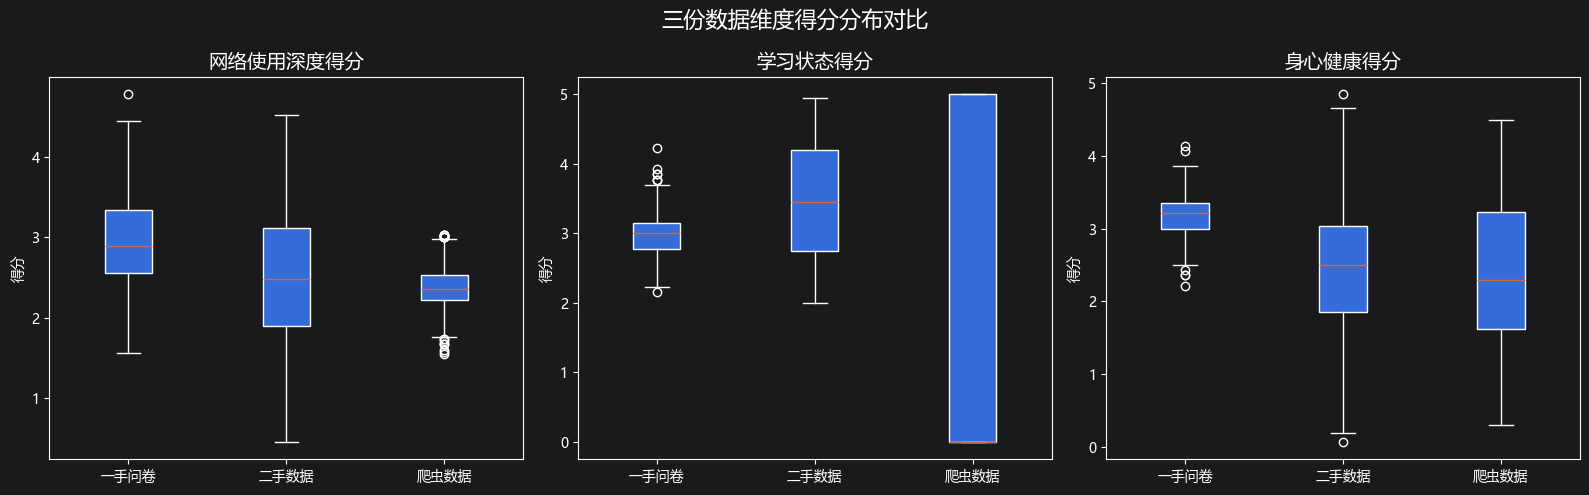

已保存: 维度得分对比.png


In [159]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

dims = ['网络使用深度得分', '学习状态得分', '身心健康得分']

for i, dim in enumerate(dims):
    data_list = []
    labels = []
    for name, d in [('一手问卷', df_survey), ('二手数据', df_second), ('爬虫数据', df_crawled)]:
        if dim in d.columns:
            data_list.append(d[dim].dropna())
            labels.append(name)
    axes[i].boxplot(data_list, labels=labels, patch_artist=True)
    axes[i].set_title(dim, fontsize=14)
    axes[i].set_ylabel('得分')

plt.suptitle('三份数据维度得分分布对比', fontsize=16)
plt.tight_layout()
plt.savefig(DATA_DIR / '维度得分对比.png', dpi=150, bbox_inches='tight')
plt.show()
print('已保存: 维度得分对比.png')